# LLM APIs: Temperature, Classification & NER

In this notebook we will:

- Quickly **revise chat roles**: `system`, `user`, `assistant`
- Understand **LLM parameters** like `temperature`, `top_p`, `max_tokens`, etc.
- Use LLMs for **text classification**:
  - Binary: spam / not spam
  - Multi-class: topic of a political text
- Use LLMs for **Named Entity Recognition (NER)**:
  - Find people, organisations, countries, etc. in text

We will go step by step.

In [92]:
# Basic imports used later
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from openai import OpenAI

# Put your OpenRouter API key here (just like in previous lecture)
OPENROUTER_API_KEY = ""
MODEL_NAME="qwen/qwen3-14b:free"

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

## 1. Revision — Chat roles

Three basic roles in chat APIs:

- **system** — sets the rules, instructions, “job description” for the model
  > Example: *"You are a helpful assistant that answers briefly."*

- **user** — what the human writes / asks
  > Example: *"Explain what inflation is in one sentence."*

- **assistant** — what the model answers
  > The response generated by the LLM.

We send a **list of messages** (history) to the model.


In [93]:
messages_example = [
    {"role": "system", "content": "You are a very short, clear assistant."},
    {"role": "user", "content": "Explain what a democracy is in one sentence."},
]

response = client.chat.completions.create(
    model=MODEL_NAME,
    messages=messages_example,
)

print("Assistant answer:")
print(response.choices[0].message.content)

Assistant answer:
A democracy is a system of government where the people have the power to make decisions through voting.


## 2. Temperature and other sampling parameters

When we ask the LLM for text, it doesn't always give the **same** answer.
We can control how **random** / **creative** it is with some parameters:

- **temperature**
  - `0.0-0.5` → very *deterministic*, boring, but stable
  - `0.6-1.0` → more creative, more variety
  - `1.1-2.0` → very random, can be weird

- **top_p** (nucleus sampling)
  - Instead of using all words, the model chooses from the **most probable words**
  - `top_p = 0.9` → keep only words that together have 90% probability

- **max_tokens**
  - Maximum length of the answer (in tokens ≈ word pieces)
  - Smaller value → shorter answer, cheaper

We will experiment mainly with **temperature**.

In [94]:
def call_llm(prompt: str,
             system_prompt: str = "You are a helpful assistant.",
             temperature: float = 1.0,
             top_p: float = 1.0):
    """
    Simple helper for this notebook.
    """
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": prompt},
    ]

    resp = client.chat.completions.create(
        model=MODEL_NAME,
        messages=messages,
        temperature=temperature,
        top_p=top_p,
    )
    return resp.choices[0].message.content

In [95]:
prompt = "Write a short slogan for a political campaign about improving public healthcare."

print("=== Temperature = 0.1 (very focused) ===")
for i in range(3):
    print(f"\nRun {i+1}:")
    print(call_llm(prompt, temperature=0.1))

print("\n\n=== Temperature = 1.5 (very creative) ===")
for i in range(3):
    print(f"\nRun {i+1}:")
    print(call_llm(prompt, temperature=1.5))


=== Temperature = 0.1 (very focused) ===

Run 1:
"Healthy Nation, Stronger Future – Invest in Public Healthcare!"

Run 2:
"Healthy Nation, Stronger Future – Invest in Public Healthcare!"

Run 3:
"Healthy Nation, Stronger Future – Invest in Public Healthcare!"


=== Temperature = 1.5 (very creative) ===

Run 1:
"Healthier Futures, Stronger Communities — Invest in Public Healthcare Now!"

Run 2:
"Healthy Families, Stronger Future — Invest in Public Healthcare!"

Run 3:
“Healthy Nation, Stronger Future.”


### What to notice

- At **temperature = 0.1**, the answer is usually almost the **same every time**.
- At **temperature = 1.5**, the answers are more **diverse**, sometimes strange.

In real projects:
- For **classification / analysis** → often use **low temperature** (e.g. 0.1–0.3)
- For **creative texts** (stories, slogans) → higher temperature (e.g. 1.2–1.7+)


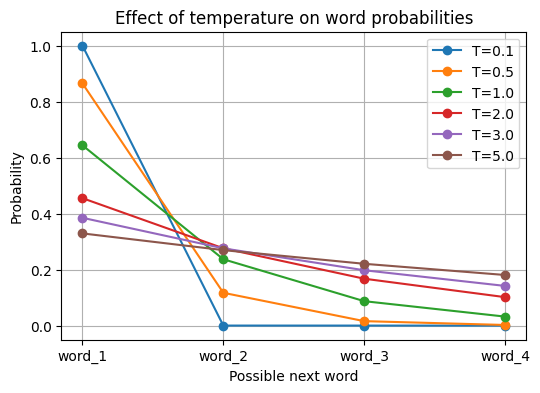

In [96]:
# This is a toy example to *visualize* temperature.
# Imagine 4 possible words with some scores (logits).
logits = np.array([2.0, 1.0, 0.0, -1.0])  # arbitrary scores

def softmax(x):
    ex = np.exp(x - np.max(x))
    return ex / ex.sum()

temperatures = [0.1, 0.5, 1.0, 2.0, 3.0, 5.0]

plt.figure(figsize=(6, 4))

for T in temperatures:
    probs = softmax(logits / T)
    plt.plot(range(len(logits)), probs, marker="o", label=f"T={T}")

plt.xticks(range(len(logits)), ["word_1", "word_2", "word_3", "word_4"])
plt.xlabel("Possible next word")
plt.ylabel("Probability")
plt.title("Effect of temperature on word probabilities")
plt.legend()
plt.grid(True)
plt.show()


### Interpreting the temperature plot

- At **low temperature** (e.g. T = 0.1):
  - The most probable word gets **almost all** the probability.
- At **high temperature** (e.g. T = 5.0):
  - Probabilities are **more spread out**, more different words are possible.

This is why higher temperature gives more **variety** and sometimes more **nonsense**.


In [97]:
# ---- Dataset 1: spam / not spam ----
emails = [
    "WIN a FREE vacation to Paris!!! Click here now!!!",
    "Dear student, your timetable for next semester is attached.",
    "Limited offer: Make money fast from home. Sign up today!",
    "Can we move our meeting to 3pm tomorrow?",
    "You have been selected for a cash prize. Just share your bank details.",
    "Hi, just checking if you received my last email about the report.",
    "Breaking: Government introduces new tax reform. Read the details here.",
    "Congratulations, you are pre-approved for a secret credit card!"
]

labels_spam = [
    1,  # spam
    0,  # not spam
    1,
    0,
    1,
    0,
    0,
    1,
]

df_emails = pd.DataFrame({
    "text": emails,
    "is_spam": labels_spam
})

# ---- Dataset 2: short political texts with topic ----
texts_politics = [
    "The government announced a new tax cut for small businesses.",
    "Doctors warned that hospitals need more funding to handle winter season.",
    "Teachers are protesting low salaries and crowded classrooms.",
    "The president met with EU leaders to discuss border security.",
    "A new program will help unemployed people find jobs and training.",
    "The city plans to build new tram lines to reduce traffic jams.",
    "Citizens are debating changes to the constitution about presidential powers.",
    "The ministry introduced a new vaccination campaign for children.",
    "The prime minister visited a factory to talk about export growth.",
    "Students organised a march demanding lower university fees."
]

topics = [
    "economy",
    "health",
    "education",
    "foreign_policy",
    "economy",
    "infrastructure",
    "constitution",
    "health",
    "economy",
    "education",
]

df_politics = pd.DataFrame({
    "text": texts_politics,
    "topic": topics
})

df_emails, df_politics.head()

(                                                text  is_spam
 0  WIN a FREE vacation to Paris!!! Click here now!!!        1
 1  Dear student, your timetable for next semester...        0
 2  Limited offer: Make money fast from home. Sign...        1
 3           Can we move our meeting to 3pm tomorrow?        0
 4  You have been selected for a cash prize. Just ...        1
 5  Hi, just checking if you received my last emai...        0
 6  Breaking: Government introduces new tax reform...        0
 7  Congratulations, you are pre-approved for a se...        1,
                                                 text           topic
 0  The government announced a new tax cut for sma...         economy
 1  Doctors warned that hospitals need more fundin...          health
 2  Teachers are protesting low salaries and crowd...       education
 3  The president met with EU leaders to discuss b...  foreign_policy
 4  A new program will help unemployed people find...         economy)

## 4. Binary classification: spam vs not spam

Goal: For each message, predict:

- `1` → spam
- `0` → not spam

We will ask the LLM to act like a **spam filter** and return a **tiny JSON object**.


In [98]:
def classify_spam_llm(text: str, temperature: float) -> int:
    """
    Returns 1 for spam, 0 for not spam.
    Uses a very explicit instruction and JSON output.
    """
    system_prompt = """
You are a spam filter for email messages.

Decide if the message is spam or not spam.

Return ONLY a JSON object like:
{"spam": true}
or
{"spam": false}

No explanation, no extra text, no ``` marks.
""".strip()

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": text},
    ]

    try:
        resp = client.chat.completions.create(
            model=MODEL_NAME,
            messages=messages,
            temperature=temperature,
        )
        raw = resp.choices[0].message.content.strip()
        print("Model raw output:", raw)
        obj = json.loads(raw)
        return 1 if obj.get("spam", False) else 0
    except Exception as e:
        print("Error parsing model output:", e)
        return -1  # error code


In [99]:
test_email = "WIN a FREE iPhone!!! Click here to claim your prize now!"
pred = classify_spam_llm(test_email, temperature=0.1)
print("Predicted spam:", pred)

Model raw output: {"spam": true}
Predicted spam: 1


In [100]:
df_emails["pred_spam"] = 0

for i in range(len(df_emails)):
    print("\n=== Row", i, "===")
    text = df_emails.loc[i, "text"]
    df_emails.loc[i, "pred_spam"] = classify_spam_llm(text, temperature=0.1)

df_emails


=== Row 0 ===
Model raw output: {"spam": true}

=== Row 1 ===
Model raw output: {"spam": false}

=== Row 2 ===
Model raw output: {"spam": true}

=== Row 3 ===
Model raw output: {"spam": false}

=== Row 4 ===
Model raw output: {"spam": true}

=== Row 5 ===
Model raw output: {"spam": false}

=== Row 6 ===
Model raw output: {"spam": false}

=== Row 7 ===
Model raw output: {"spam": true}


,text,is_spam,pred_spam
0,WIN a FREE vacation to Paris!!! Click here now!!!,1,1
1,"Dear student, your timetable for next semester...",0,0
2,Limited offer: Make money fast from home. Sign...,1,1
3,Can we move our meeting to 3pm tomorrow?,0,0
4,You have been selected for a cash prize. Just ...,1,1
5,"Hi, just checking if you received my last emai...",0,0
6,Breaking: Government introduces new tax reform...,0,0
7,"Congratulations, you are pre-approved for a se...",1,1


In [101]:
# Simple accuracy (ignoring rows where prediction is -1)
mask_valid = df_emails["pred_spam"] >= 0
correct = (df_emails.loc[mask_valid, "is_spam"] == df_emails.loc[mask_valid, "pred_spam"]).sum()
total = mask_valid.sum()
accuracy = correct / total if total > 0 else 0

print(f"Accuracy on this tiny dataset: {accuracy:.2f}  (correct: {correct} / {total})")

Accuracy on this tiny dataset: 1.00  (correct: 8 / 8)


## 5. Multi-class classification: topic of political text

Now we want to assign each text one of several **topic labels**, for example:

- `economy`
- `health`
- `education`
- `foreign_policy`
- `infrastructure`
- `constitution`
- `other`

Again, we will ask the LLM to return a **single label in JSON**.


In [102]:
TOPIC_LABELS = [
    "economy",
    "health",
    "education",
    "foreign_policy",
    "infrastructure",
    "constitution",
    "other",
]

def classify_topic_llm(text: str) -> str:
    """
    Returns one of the topic labels as a string.
    """
    system_prompt = f"""
You are a political science assistant.

Read the short text about politics and classify it into ONE topic.

Allowed topics (use EXACT spelling):
{", ".join(TOPIC_LABELS)}

Return ONLY a JSON object like:
{{"topic": "economy"}}

No explanation, no extra text, no ``` marks.
""".strip()

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": text},
    ]

    try:
        resp = client.chat.completions.create(
            model=MODEL_NAME,
            messages=messages,
            temperature=0.1,
        )
        raw = resp.choices[0].message.content.strip()
        print("Model raw output:", raw)
        obj = json.loads(raw)
        topic = obj.get("topic", "other")
        if topic not in TOPIC_LABELS:
            topic = "other"
        return topic
    except Exception as e:
        print("Error parsing model output:", e)
        return "other"


In [103]:
test_text = "The government plans to increase spending on hospitals and medical staff."
pred_topic = classify_topic_llm(test_text)
print("Predicted topic:", pred_topic)

Model raw output: {"topic": "health"}
Predicted topic: health


In [104]:
df_politics["pred_topic"] = ""

for i in range(len(df_politics)):
    print("\n=== Row", i, "===")
    text = df_politics.loc[i, "text"]
    df_politics.loc[i, "pred_topic"] = classify_topic_llm(text)

df_politics


=== Row 0 ===
Model raw output: {"topic": "economy"}

=== Row 1 ===
Model raw output: {"topic": "health"}

=== Row 2 ===
Model raw output: {"topic": "education"}

=== Row 3 ===
Model raw output: {"topic": "foreign_policy"}

=== Row 4 ===
Model raw output: {"topic": "economy"}

=== Row 5 ===
Model raw output: {"topic": "infrastructure"}

=== Row 6 ===
Model raw output: {"topic": "constitution"}

=== Row 7 ===
Model raw output: {"topic": "health"}

=== Row 8 ===
Model raw output: {"topic": "economy"}

=== Row 9 ===
Model raw output: {"topic": "education"}


,text,topic,pred_topic
0,The government announced a new tax cut for sma...,economy,economy
1,Doctors warned that hospitals need more fundin...,health,health
2,Teachers are protesting low salaries and crowd...,education,education
3,The president met with EU leaders to discuss b...,foreign_policy,foreign_policy
4,A new program will help unemployed people find...,economy,economy
5,The city plans to build new tram lines to redu...,infrastructure,infrastructure
6,Citizens are debating changes to the constitut...,constitution,constitution
7,The ministry introduced a new vaccination camp...,health,health
8,The prime minister visited a factory to talk a...,economy,economy
9,Students organised a march demanding lower uni...,education,education


In [105]:
correct = (df_politics["topic"] == df_politics["pred_topic"]).sum()
total = len(df_politics)
accuracy = correct / total if total > 0 else 0
print(f"Topic classification accuracy: {accuracy:.2f}  (correct: {correct} / {total})")

Topic classification accuracy: 1.00  (correct: 10 / 10)


## 6. Named Entity Recognition (NER) with LLMs

**Named Entity Recognition (NER)** = finding “important names” in text, e.g.:

- People (PERSON)
- Countries / cities (LOCATION)
- Institutions (ORGANIZATION)
- Dates, laws, parties, etc.

Example text:

> "Prime Minister Anna Kowalska met with the European Commission in Brussels on Monday."

Entities:
- `Anna Kowalska` → PERSON
- `European Commission` → ORGANIZATION
- `Brussels` → LOCATION
- `Monday` → DATE

We will ask the LLM to extract entities and return a JSON list.


In [106]:
texts_ner = [
    "Prime Minister Anna Kowalska met with the European Commission in Brussels on Monday.",
    "The new climate agreement was signed by leaders from France, Germany and Poland.",
    "The Constitutional Court decided that the new media law is incompatible with the constitution.",
    "President John Smith visited Warsaw to discuss defense cooperation with NATO officials.",
    "The health minister announced a vaccination campaign in cooperation with the World Health Organization.",
]

df_ner = pd.DataFrame({"text": texts_ner})
df_ner

,text
0,Prime Minister Anna Kowalska met with the Euro...
1,The new climate agreement was signed by leader...
2,The Constitutional Court decided that the new ...
3,President John Smith visited Warsaw to discuss...
4,The health minister announced a vaccination ca...


In [107]:
def extract_entities_llm(text: str):
    system_prompt = """
You are an information extraction system for political science.

Task:
- Read the text.
- Extract all important named entities.
- Use these types (exact spelling):

  - PERSON
  - PARTY
  - INSTITUTION
  - INT_ORG
  - COUNTRY_OR_REGION
  - CITY_OR_PLACE
  - LAW_OR_DOCUMENT
  - ELECTION_OR_REFERENDUM
  - DATE
  - OTHER

Return ONLY a JSON array of objects like:
[
  {"text": "something", "type": "PERSON"},
  {"text": "something else", "type": "PARTY"}
]

No explanation, no comments, no ``` marks.
""".strip()

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": text},
    ]

    try:
        resp = client.chat.completions.create(
            model=MODEL_NAME,
            messages=messages,
            temperature=0.1,
        )
        raw = resp.choices[0].message.content.strip()
        print("Model raw output:\n", raw)
        entities = json.loads(raw)
        return entities
    except Exception as e:
        print("Error parsing entities:", e)
        return []


In [108]:
example_text = df_ner.loc[0, "text"]
entities = extract_entities_llm(example_text)
print("\nParsed entities:")
for ent in entities:
    print(f"- {ent['text']} ({ent['type']})")

Model raw output:
 [
  {"text": "Anna Kowalska", "type": "PERSON"},
  {"text": "European Commission", "type": "INT_ORG"},
  {"text": "Brussels", "type": "CITY_OR_PLACE"},
  {"text": "Monday", "type": "DATE"}
]

Parsed entities:
- Anna Kowalska (PERSON)
- European Commission (INT_ORG)
- Brussels (CITY_OR_PLACE)
- Monday (DATE)


In [109]:
df_ner["entities"] = ""

for i in range(len(df_ner)):
    print("\n=== Row", i, "===")
    text = df_ner.loc[i, "text"]
    ents = extract_entities_llm(text)
    df_ner.loc[i, "entities"] = json.dumps(ents, ensure_ascii=False, indent=2)

df_ner



=== Row 0 ===
Model raw output:
 [
  {"text": "Anna Kowalska", "type": "PERSON"},
  {"text": "European Commission", "type": "INT_ORG"},
  {"text": "Brussels", "type": "CITY_OR_PLACE"},
  {"text": "Monday", "type": "DATE"}
]

=== Row 1 ===
Model raw output:
 [
  {"text": "France", "type": "COUNTRY_OR_REGION"},
  {"text": "Germany", "type": "COUNTRY_OR_REGION"},
  {"text": "Poland", "type": "COUNTRY_OR_REGION"}
]

=== Row 2 ===
Model raw output:
 [
  {"text": "Constitutional Court", "type": "INSTITUTION"},
  {"text": "constitution", "type": "LAW_OR_DOCUMENT"},
  {"text": "new media law", "type": "LAW_OR_DOCUMENT"}
]

=== Row 3 ===
Model raw output:
 [
  {"text": "John Smith", "type": "PERSON"},
  {"text": "Warsaw", "type": "CITY_OR_PLACE"},
  {"text": "NATO", "type": "INT_ORG"}
]

=== Row 4 ===
Model raw output:
 [
  {"text": "health minister", "type": "PERSON"},
  {"text": "World Health Organization", "type": "INT_ORG"}
]


,text,entities
0,Prime Minister Anna Kowalska met with the Euro...,"[\n {\n ""text"": ""Anna Kowalska"",\n ""typ..."
1,The new climate agreement was signed by leader...,"[\n {\n ""text"": ""France"",\n ""type"": ""CO..."
2,The Constitutional Court decided that the new ...,"[\n {\n ""text"": ""Constitutional Court"",\n ..."
3,President John Smith visited Warsaw to discuss...,"[\n {\n ""text"": ""John Smith"",\n ""type"":..."
4,The health minister announced a vaccination ca...,"[\n {\n ""text"": ""health minister"",\n ""t..."


## 8. NER in real political texts + few-shot prompting

So far we did very simple NER.

Now we add **more realistic political examples** and use the **few-shot technique**:
- We show the model **several examples** of what we want (input → JSON output)
- Then we give a **new text** and the model tries to copy the pattern

This is like:
> "Look, model, here are 2–3 solved tasks.
> Now do the same with this new sentence."


### Entity types for political NER

We will use a slightly richer set of labels:

- `PERSON` – individual people
  > e.g. *"Anna Kowalska"*, *"Donald Tusk"*

- `PARTY` – political parties
  > e.g. *"Law and Justice"*, *"Civic Platform"*, *"PiS"*, *"PO"*

- `INSTITUTION` – national institutions, courts, ministries, parliament
  > e.g. *"Sejm"*, *"Polish Supreme Court"*, *"Ministry of Finance"*

- `INT_ORG` – international organisations
  > e.g. *"European Union"*, *"NATO"*, *"European Commission"*

- `COUNTRY_OR_REGION`
  > e.g. *"Poland"*, *"United Kingdom"*, *"Silesia"*

- `CITY_OR_PLACE`
  > e.g. *"Warsaw"*, *"Brussels"*, *"Downing Street"*

- `LAW_OR_DOCUMENT` – specific laws, treaties, constitutions
  > e.g. *"Treaty of Lisbon"*, *"Article 7 of the Treaty on European Union"*

- `ELECTION_OR_REFERENDUM`
  > e.g. *"2016 Brexit referendum"*, *"2023 parliamentary election"*

- `DATE` – explicit dates / years
  > e.g. *"2016"*, *"October 15, 2023"*

- `OTHER` – important named things that don’t fit above

We will give the model **few-shot examples** of how to mark these.

In [110]:
# A few tricky political examples we will use
political_ner_texts = [
    # 0
    "In 2016, the British people voted in the Brexit referendum, which led to the United Kingdom leaving the European Union.",
    # 1
    "According to Article 7 of the Treaty on European Union, the Council may suspend certain rights of a Member State.",
    # 2
    "Law and Justice (PiS) lost its majority in the Sejm after the 2023 parliamentary election in Poland.",
    # 3
    "The European Commission launched an infringement procedure against Hungary over its new media law.",
    # 4
    "During the summit in Brussels, President Emmanuel Macron met with NATO leaders to discuss security in Eastern Europe.",
]

pd.DataFrame({"id": range(len(political_ner_texts)), "text": political_ner_texts})

,id,text
0,0,"In 2016, the British people voted in the Brexi..."
1,1,According to Article 7 of the Treaty on Europe...
2,2,Law and Justice (PiS) lost its majority in the...
3,3,The European Commission launched an infringeme...
4,4,"During the summit in Brussels, President Emman..."


In [111]:
def extract_entities_llm_few_shot(text: str):
    system_prompt = """
You are an information extraction system for political science.

Task:
- Read the text.
- Extract all important named entities.
- Use these types (exact spelling):

  - PERSON
  - PARTY
  - INSTITUTION
  - INT_ORG
  - COUNTRY_OR_REGION
  - CITY_OR_PLACE
  - LAW_OR_DOCUMENT
  - ELECTION_OR_REFERENDUM
  - DATE
  - OTHER

Return ONLY a JSON array of objects like:
[
  {"text": "something", "type": "PERSON"},
  {"text": "something else", "type": "PARTY"}
]

No explanation, no comments, no ``` marks.
""".strip()

    # ---------- FEW-SHOT EXAMPLE 1 ----------
    example_text_1 = (
        "Law and Justice (PiS) lost its majority in the Sejm after the 2023 "
        "parliamentary election in Poland."
    )
    example_answer_1 = json.dumps([
        {"text": "Law and Justice", "type": "PARTY"},
        {"text": "PiS", "type": "PARTY"},
        {"text": "Sejm", "type": "INSTITUTION"},
        {"text": "2023 parliamentary election", "type": "ELECTION_OR_REFERENDUM"},
        {"text": "Poland", "type": "COUNTRY_OR_REGION"},
        {"text": "2023", "type": "DATE"}
    ], ensure_ascii=False, indent=2)

    # ---------- FEW-SHOT EXAMPLE 2 ----------
    example_text_2 = (
        "According to Article 7 of the Treaty on European Union, "
        "the Council may suspend certain rights of a Member State."
    )
    example_answer_2 = json.dumps([
        {"text": "Article 7", "type": "LAW_OR_DOCUMENT"},
        {"text": "Treaty on European Union", "type": "LAW_OR_DOCUMENT"},
        {"text": "Council", "type": "INSTITUTION"},
        {"text": "Member State", "type": "OTHER"}
    ], ensure_ascii=False, indent=2)

    messages = [
        {"role": "system", "content": system_prompt},

        # Example 1
        {"role": "user", "content": example_text_1},
        {"role": "assistant", "content": example_answer_1},

        # Example 2
        {"role": "user", "content": example_text_2},
        {"role": "assistant", "content": example_answer_2},

        # Real input
        {"role": "user", "content": text},
    ]

    try:
        resp = client.chat.completions.create(
            model=MODEL_NAME,
            messages=messages,
            temperature=0.1,   # deterministic for extraction
        )
        raw = resp.choices[0].message.content.strip()
        print("Model raw output:\n", raw)
        entities = json.loads(raw)
        return entities
    except Exception as e:
        print("Error parsing entities:", e)
        return []


In [112]:
example_index = 1
example_text = political_ner_texts[example_index]
print("TEXT:")
print(example_text)

entities_fs = extract_entities_llm_few_shot(example_text)

print("\nParsed entities (few-shot):")
for ent in entities_fs:
    print(f"- {ent['text']} ({ent['type']})")

entities_zero = extract_entities_llm(example_text)
print("\nParsed entities (zero-shot):")
for ent in entities_zero:
    print(f"- {ent['text']} ({ent['type']})")

TEXT:
According to Article 7 of the Treaty on European Union, the Council may suspend certain rights of a Member State.
Model raw output:
 [
  {
    "text": "Article 7",
    "type": "LAW_OR_DOCUMENT"
  },
  {
    "text": "Treaty on European Union",
    "type": "LAW_OR_DOCUMENT"
  },
  {
    "text": "Council",
    "type": "INSTITUTION"
  },
  {
    "text": "Member State",
    "type": "OTHER"
  }
]

Parsed entities (few-shot):
- Article 7 (LAW_OR_DOCUMENT)
- Treaty on European Union (LAW_OR_DOCUMENT)
- Council (INSTITUTION)
- Member State (OTHER)
Model raw output:
 [
  {"text": "Article 7", "type": "LAW_OR_DOCUMENT"},
  {"text": "Treaty on European Union", "type": "LAW_OR_DOCUMENT"},
  {"text": "Council", "type": "INSTITUTION"},
  {"text": "Member State", "type": "COUNTRY_OR_REGION"}
]

Parsed entities (zero-shot):
- Article 7 (LAW_OR_DOCUMENT)
- Treaty on European Union (LAW_OR_DOCUMENT)
- Council (INSTITUTION)
- Member State (COUNTRY_OR_REGION)
